In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_student_data
from src.preprocessing import (
    create_target,
    create_features_and_target,
    build_preprocessor
)
from src.knn_model import select_best_k, build_knn
from src.svm_model import tune_svm, build_svm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import time

CLASS_ORDER = ["Low", "Medium", "High"]

## 1. Load data and recreate the target / train-test split

This notebook builds on Member 1 (data audit/EDA) and Member 2 (target
definition, feature selection, preprocessing pipeline, baseline).

The same target definition, feature set, and train/test split as
`02_preprocessing_baseline.ipynb` are reused here (`test_size=0.2`,
`random_state=42`, stratified by class) so that KNN and SVM are
compared against the baseline on the exact same test set.

In [2]:
df = load_student_data()
df = create_target(df)

X, y = create_features_and_target(df)

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts().reindex(CLASS_ORDER))

Feature matrix shape: (395, 32)
Target distribution:
performance_class
Low       130
Medium    192
High       73
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().reindex(CLASS_ORDER))

print("\nTest class distribution:")
print(y_test.value_counts().reindex(CLASS_ORDER))

Training set: (316, 32)
Test set: (79, 32)

Training class distribution:
performance_class
Low       104
Medium    154
High       58
Name: count, dtype: int64

Test class distribution:
performance_class
Low       26
Medium    38
High      15
Name: count, dtype: int64


In [4]:
preprocessor = build_preprocessor()

## 2. K-Nearest Neighbors (KNN)

KNN classifies a student by looking at the `k` most similar students
(by feature distance) in the training data and taking a majority vote
of their performance class.

Because KNN relies on distance, features on different numeric scales
(e.g. `age` in years vs. `absences` in days) would otherwise distort
the distance calculation — a feature with a naturally larger range
would dominate the distance even if it isn't more informative. This is
why the preprocessing pipeline scales numerical features with
`StandardScaler` before they reach the KNN classifier.

### 2.1 Choosing k

`k` is selected using 5-fold stratified cross-validation on the
**training data only** (the test set is not touched at this stage).
Macro-F1 is used as the selection metric rather than accuracy, since
the performance classes are imbalanced (Medium is the largest class,
High is the smallest) and macro-F1 weighs all three classes equally.

In [5]:
knn_cv_results, best_k = select_best_k(
    preprocessor,
    X_train,
    y_train,
    k_values=[3, 5, 7, 9, 11]
)

knn_cv_results

,k,mean_f1_macro,std_f1_macro
0,3,0.601002,0.048736
1,5,0.627473,0.033775
2,7,0.629248,0.057947
3,9,0.677073,0.045853
4,11,0.669596,0.065974


In [6]:
print(f"Selected k = {best_k}")

Selected k = 9


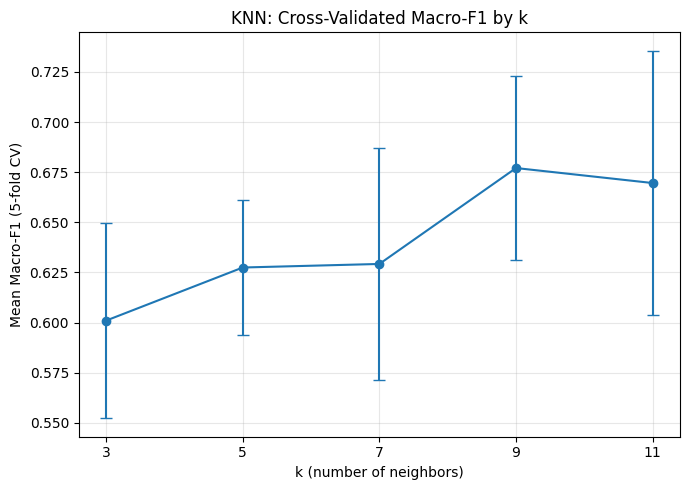

In [7]:
plt.figure(figsize=(7, 5))

plt.errorbar(
    knn_cv_results["k"],
    knn_cv_results["mean_f1_macro"],
    yerr=knn_cv_results["std_f1_macro"],
    marker="o",
    capsize=4
)

plt.title("KNN: Cross-Validated Macro-F1 by k")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Mean Macro-F1 (5-fold CV)")
plt.xticks(knn_cv_results["k"])
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "knn_k_selection.png",
    dpi=300
)

plt.show()

### 2.2 Final KNN model and test-set evaluation

The final KNN model is trained on the full training set using the
selected `k`, then evaluated once on the untouched test set.

In [8]:
knn_model = build_knn(preprocessor, n_neighbors=best_k)

start = time.time()
knn_model.fit(X_train, y_train)
knn_train_time = time.time() - start

start = time.time()
y_pred_knn = knn_model.predict(X_test)
knn_predict_time = time.time() - start

print(f"KNN training time: {knn_train_time:.4f} s")
print(f"KNN prediction time (test set): {knn_predict_time:.4f} s")

KNN training time: 0.0114 s
KNN prediction time (test set): 0.0060 s


In [9]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision, knn_recall, knn_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_knn, average="macro", labels=CLASS_ORDER
)

print(f"KNN Accuracy:        {knn_accuracy:.4f}")
print(f"KNN Macro Precision: {knn_precision:.4f}")
print(f"KNN Macro Recall:    {knn_recall:.4f}")
print(f"KNN Macro F1:        {knn_f1:.4f}")

print("\nClass-wise report:")
print(classification_report(y_test, y_pred_knn, labels=CLASS_ORDER))

KNN Accuracy:        0.6076
KNN Macro Precision: 0.6207
KNN Macro Recall:    0.5947
KNN Macro F1:        0.6014

Class-wise report:
              precision    recall  f1-score   support

         Low       0.68      0.50      0.58        26
      Medium       0.58      0.68      0.63        38
        High       0.60      0.60      0.60        15

    accuracy                           0.61        79
   macro avg       0.62      0.59      0.60        79
weighted avg       0.62      0.61      0.61        79



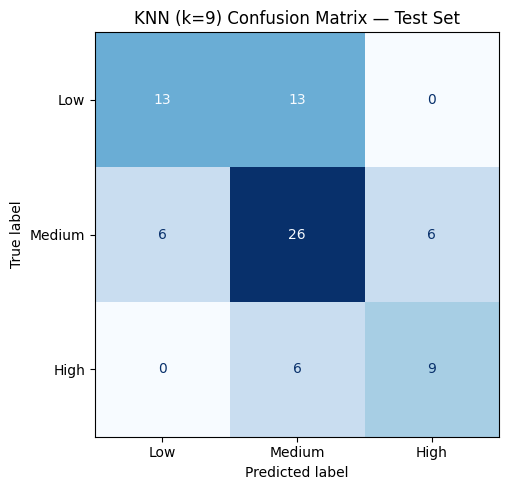

In [10]:
knn_cm = confusion_matrix(y_test, y_pred_knn, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=knn_cm,
    display_labels=CLASS_ORDER
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"KNN (k={best_k}) Confusion Matrix — Test Set")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "knn_confusion_matrix.png",
    dpi=300
)

plt.show()

## 3. Support Vector Machine (SVM)

SVM looks for a decision boundary that best separates the performance
classes in (transformed) feature space. The choice of kernel, `C`
(regularization strength) and `gamma` (for the RBF kernel) all affect
where that boundary is drawn, so they are tuned rather than guessed.

### 3.1 Hyperparameter tuning

A grid search with 5-fold stratified cross-validation (training data
only) is used to select the kernel and its parameters, again scoring
on macro-F1 for the same class-imbalance reason as KNN.

In [11]:
svm_grid_search, svm_cv_results = tune_svm(
    preprocessor,
    X_train,
    y_train
)

print("Best parameters:", svm_grid_search.best_params_)
print(f"Best CV macro-F1: {svm_grid_search.best_score_:.4f}")

Best parameters: {'classifier__C': 10, 'classifier__kernel': 'linear'}
Best CV macro-F1: 0.8058


In [12]:
svm_cv_results_sorted = svm_cv_results.sort_values(
    "mean_test_score", ascending=False
)[
    ["param_classifier__kernel", "param_classifier__C",
     "param_classifier__gamma", "mean_test_score", "std_test_score"]
].head(10)

svm_cv_results_sorted

,param_classifier__kernel,param_classifier__C,param_classifier__gamma,mean_test_score,std_test_score
18,linear,10.0,NaN,0.805828,0.043524
9,rbf,10.0,0.01,0.801278,0.036448
13,rbf,100.0,0.01,0.798688,0.034834
16,linear,0.1,NaN,0.795389,0.027155
19,linear,100.0,NaN,0.794950,0.039535
17,linear,1.0,NaN,0.789645,0.052014
12,rbf,100.0,scale,0.768403,0.035126
8,rbf,10.0,scale,0.764135,0.028209
5,rbf,1.0,0.01,0.760530,0.036115
4,rbf,1.0,scale,0.748594,0.023872


### 3.2 Final SVM model and test-set evaluation

The best estimator found by the grid search is refit on the full
training set and evaluated once on the same untouched test set used
for KNN and the baseline.

In [13]:
svm_model = svm_grid_search.best_estimator_

start = time.time()
svm_model.fit(X_train, y_train)
svm_train_time = time.time() - start

start = time.time()
y_pred_svm = svm_model.predict(X_test)
svm_predict_time = time.time() - start

print(f"SVM training time: {svm_train_time:.4f} s")
print(f"SVM prediction time (test set): {svm_predict_time:.4f} s")

SVM training time: 0.0155 s
SVM prediction time (test set): 0.0051 s


In [14]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision, svm_recall, svm_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_svm, average="macro", labels=CLASS_ORDER
)

print(f"SVM Accuracy:        {svm_accuracy:.4f}")
print(f"SVM Macro Precision: {svm_precision:.4f}")
print(f"SVM Macro Recall:    {svm_recall:.4f}")
print(f"SVM Macro F1:        {svm_f1:.4f}")

print("\nClass-wise report:")
print(classification_report(y_test, y_pred_svm, labels=CLASS_ORDER))

SVM Accuracy:        0.8228
SVM Macro Precision: 0.8195
SVM Macro Recall:    0.8381
SVM Macro F1:        0.8269

Class-wise report:
              precision    recall  f1-score   support

         Low       0.79      0.88      0.84        26
      Medium       0.85      0.76      0.81        38
        High       0.81      0.87      0.84        15

    accuracy                           0.82        79
   macro avg       0.82      0.84      0.83        79
weighted avg       0.83      0.82      0.82        79



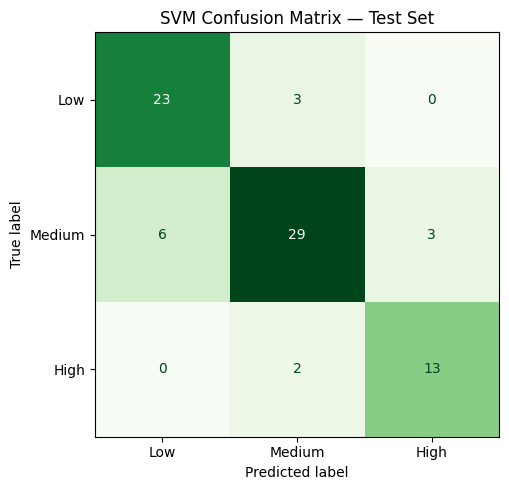

In [15]:
svm_cm = confusion_matrix(y_test, y_pred_svm, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=CLASS_ORDER
)
disp.plot(ax=ax, cmap="Greens", colorbar=False)

ax.set_title("SVM Confusion Matrix — Test Set")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "svm_confusion_matrix.png",
    dpi=300
)

plt.show()

## 4. Comparing KNN and SVM

Both models are compared on the same test set using accuracy,
macro-averaged precision/recall/F1, and training/prediction time.
Class-wise performance (from the classification reports above) is
also considered, not just the overall scores, since accuracy alone
can hide weak performance on a minority class such as High.

In [16]:
comparison = pd.DataFrame([
    {
        "Model": "KNN",
        "Best_Params": f"k={best_k}",
        "Accuracy": knn_accuracy,
        "Macro_Precision": knn_precision,
        "Macro_Recall": knn_recall,
        "Macro_F1": knn_f1,
        "Train_Time_s": knn_train_time,
        "Predict_Time_s": knn_predict_time
    },
    {
        "Model": "SVM",
        "Best_Params": str(svm_grid_search.best_params_),
        "Accuracy": svm_accuracy,
        "Macro_Precision": svm_precision,
        "Macro_Recall": svm_recall,
        "Macro_F1": svm_f1,
        "Train_Time_s": svm_train_time,
        "Predict_Time_s": svm_predict_time
    }
])

comparison

,Model,Best_Params,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Train_Time_s,Predict_Time_s
0,KNN,k=9,0.607595,0.620663,0.594737,0.601428,0.011370,0.005997
1,SVM,"{'classifier__C': 10, 'classifier__kernel': 'l...",0.822785,0.819515,0.838147,0.826876,0.015507,0.005109


In [17]:
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

knn_results_row = comparison[comparison["Model"] == "KNN"]
svm_results_row = comparison[comparison["Model"] == "SVM"]

knn_results_row.to_csv(results_dir / "knn_results.csv", index=False)
svm_results_row.to_csv(results_dir / "svm_results.csv", index=False)

print("Saved results/knn_results.csv and results/svm_results.csv")

Saved results/knn_results.csv and results/svm_results.csv


## 5. Discussion

**Overall performance.** On this test set, SVM (with a linear kernel)
clearly outperforms KNN on every aggregate metric — accuracy,
macro-precision, macro-recall, and macro-F1. Both models comfortably
beat the DummyClassifier baseline from `02_preprocessing_baseline.ipynb`
(~0.48 accuracy), confirming that the features carry real predictive
signal for performance category, but SVM extracts noticeably more of
it than KNN does here.

**Class-wise performance.** Looking at the per-class reports rather
than just the aggregate scores: KNN struggles most to distinguish
`Low` from `Medium` (the confusion matrix shows meaningful mixing
between these two adjacent classes), while `High` is comparatively
better separated. SVM's confusion matrix is much more concentrated on
the diagonal across all three classes, meaning its precision/recall
advantage isn't coming from doing well on one class at the expense of
another — it's more consistent.

**Why SVM likely does better here.** The strongest predictors in this
dataset are the prior grades (G1, G2), which are numeric and roughly
linearly related to G3 (as Member 1's EDA showed). A linear-kernel SVM
is well suited to a feature space where the classes are separated by
a fairly direct combination of a few strong numeric signals. KNN, by
contrast, uses *all* scaled features equally in its distance
calculation, so weaker or noisier features can drag "similar" students
toward the wrong neighborhood even when G1/G2 alone would have been a
good predictor.

**Runtime and complexity.** Both models train and predict quickly on
a dataset this size (well under a second each), so runtime is not a
practical differentiator here — it would matter more at a much larger
scale. In terms of complexity, KNN has almost no training cost but
must compare against the whole training set at prediction time; the
tuned linear SVM has a short training/tuning cost but very fast,
lightweight predictions afterward.

**Interpretability.** KNN's predictions can be explained by pointing
to concrete "similar students" in the training data, which is
intuitive to explain non-technically. A linear SVM is also
reasonably interpretable — its learned coefficients indicate which
(scaled/encoded) features push a prediction toward each class — though
this requires some familiarity with the one-hot/scaled feature
representation to read directly.

**Conclusion for this stage.** Based on macro-F1 and consistent
class-wise performance, **SVM (linear kernel) is the stronger
candidate of the two** on this dataset and split. This result, along
with the KNN and SVM result tables, is passed on to Member 4 for the
final comparison against Random Forest and the baseline, and for
error analysis.